In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


TrainData1 = pd.read_csv("TrainData1.txt", sep="\t", header=None)
TrainLabel1 = pd.read_csv("TrainLabel1.txt", sep="\t", header=None)[0]

TrainData2 = pd.read_csv("TrainData2.txt", sep=r"\s+", engine="python", header=None)
TrainLabel2 = pd.read_csv("TrainLabel2.txt", sep=r"\s+", engine="python", header=None)[0]

TrainData3 = pd.read_csv("TrainData3.txt", sep=r"\s+", engine="python", header=None)
TrainLabel3 = pd.read_csv("TrainLabel3.txt", sep=r"\s+", engine="python", header=None)[0]

TrainData4 = pd.read_csv("TrainData4.txt", sep=r"\s+", engine="python", header=None)
TrainLabel4 = pd.read_csv("TrainLabel4.txt", sep=r"\s+", engine="python", header=None)[0]


## Shapes & Class Counts


In [2]:
summary = pd.DataFrame({
    "Dataset": ["Dataset1", "Dataset2", "Dataset3", "Dataset4"],
    "Train_samples": [TrainData1.shape[0], TrainData2.shape[0], TrainData3.shape[0], TrainData4.shape[0]],
    "Train_features": [TrainData1.shape[1], TrainData2.shape[1], TrainData3.shape[1], TrainData4.shape[1]],
    "Num_classes": [
        TrainLabel1.nunique(),
        TrainLabel2.nunique(),
        TrainLabel3.nunique(),
        TrainLabel4.nunique()
    ]
})

summary


,Dataset,Train_samples,Train_features,Num_classes
0,Dataset1,150,3312,5
1,Dataset2,100,9182,11
2,Dataset3,2547,112,9
3,Dataset4,1119,11,6


## Missing Value Analysis 

In [3]:
def missing_analysis(df, name):
    missing_val = (df == 1e99).sum().sum()
    total = df.size
    return pd.Series({
        "Dataset": name,
        "Total_entries": total,
        "Missing_values": missing_val,
        "Missing_pct": round((missing_val / total) * 100, 6)
    })

missing_results = pd.DataFrame([
    missing_analysis(TrainData1, "Dataset1"),
    missing_analysis(TrainData2, "Dataset2"),
    missing_analysis(TrainData3, "Dataset3"),
    missing_analysis(TrainData4, "Dataset4"),
])

missing_results



,Dataset,Total_entries,Missing_values,Missing_pct
0,Dataset1,496800,9936,2.0
1,Dataset2,918200,0,0.0
2,Dataset3,285264,0,0.0
3,Dataset4,12309,0,0.0


## Class Distribution

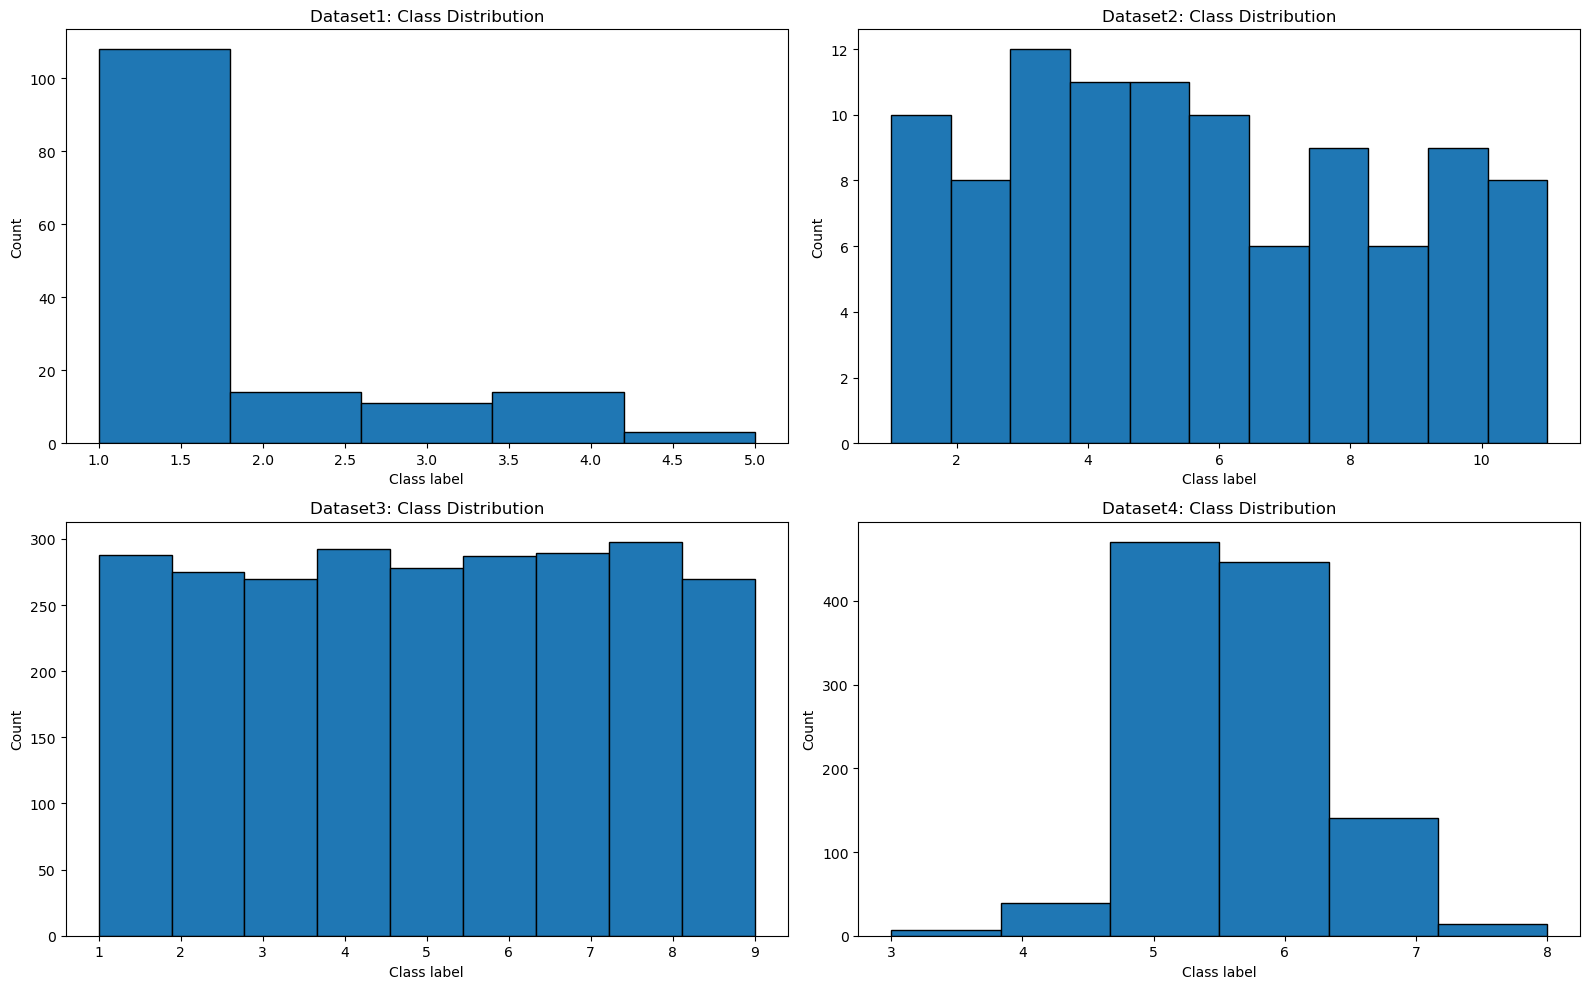

In [4]:
datasets_labels = [
    ("Dataset1", TrainLabel1),
    ("Dataset2", TrainLabel2),
    ("Dataset3", TrainLabel3),
    ("Dataset4", TrainLabel4)
]

plt.figure(figsize=(16, 10))

for i, (title, labels) in enumerate(datasets_labels, 1):
    plt.subplot(2, 2, i)
    plt.hist(labels, bins=len(labels.unique()), edgecolor='black')
    plt.title(f"{title}: Class Distribution")
    plt.xlabel("Class label")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


## Feature Distribution Analysis


=== Dataset1 Summary ===
Mean Range: 1.029  to  3.854
Std Dev Range: 0.039  to  0.979


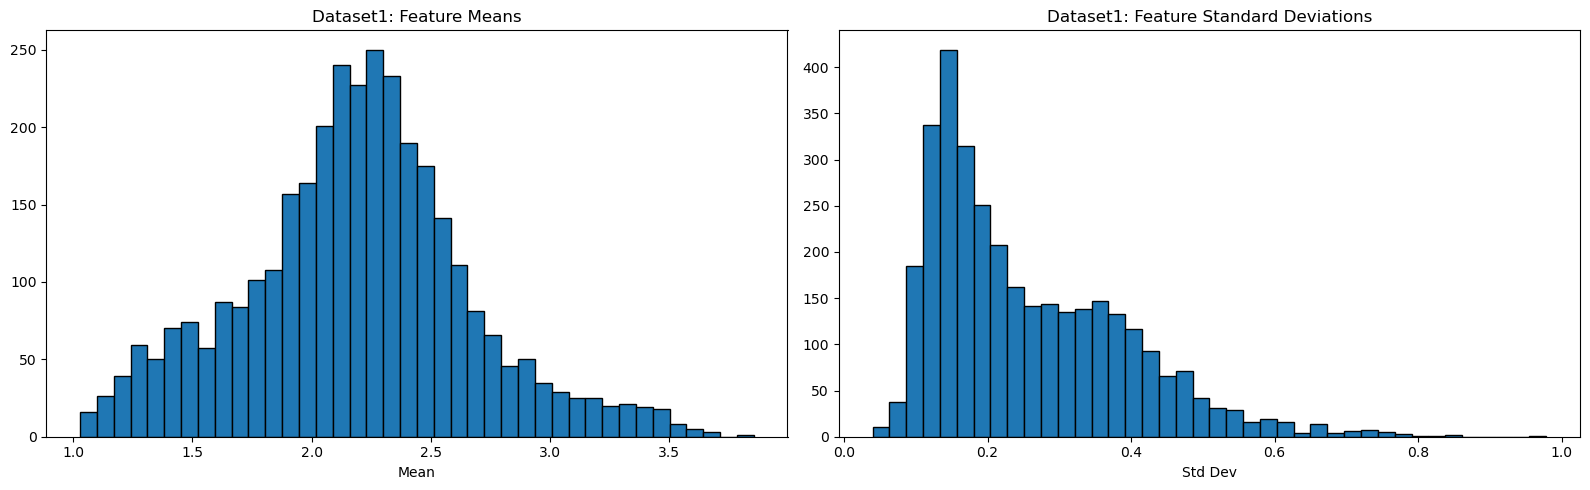


=== Dataset2 Summary ===
Mean Range: 1.311  to  4.209
Std Dev Range: 0.087  to  1.047


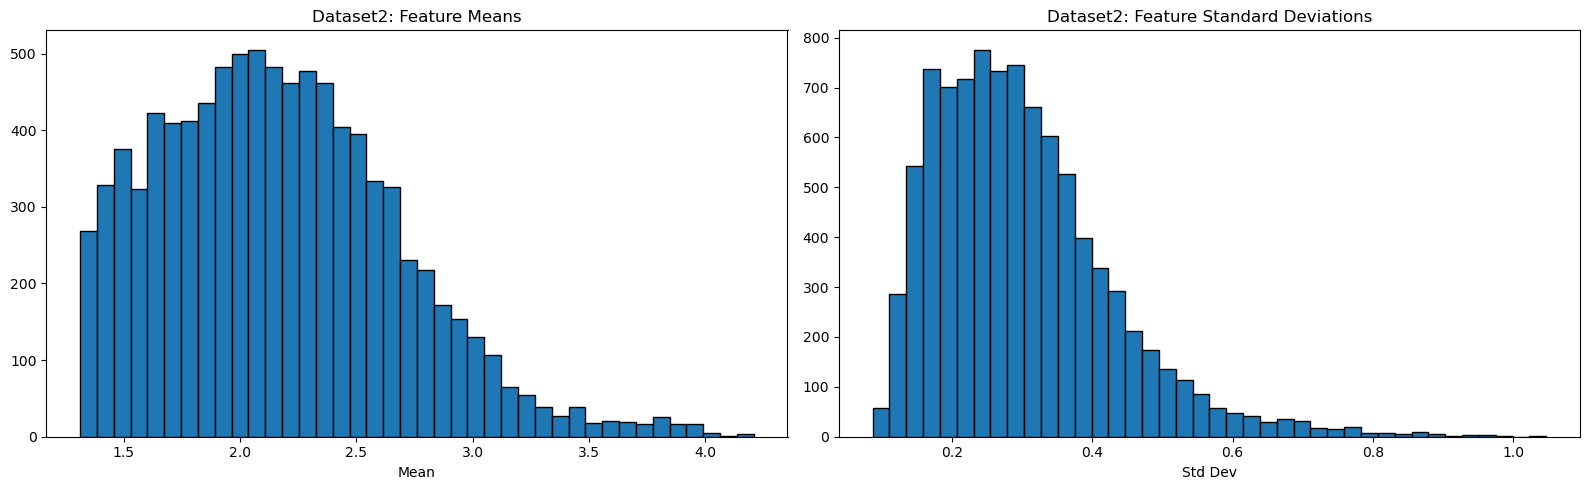


=== Dataset3 Summary ===
Mean Range: -178.773  to  118.728
Std Dev Range: 0.000  to  184.112


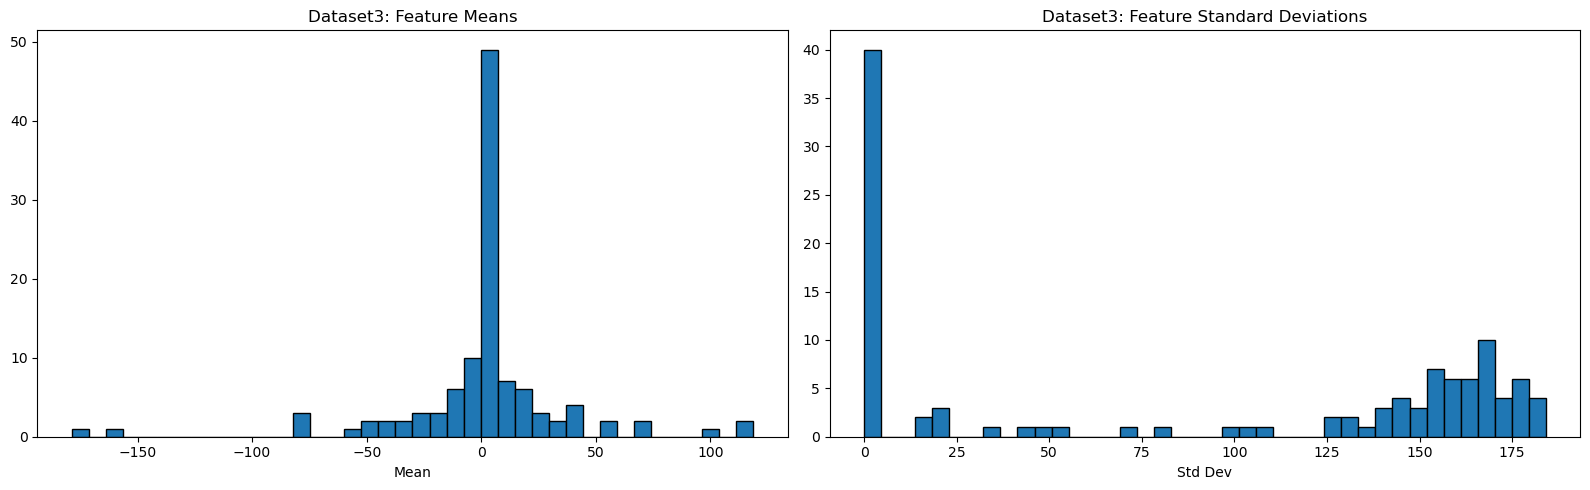


=== Dataset4 Summary ===
Mean Range: 0.087  to  46.979
Std Dev Range: 0.002  to  33.266


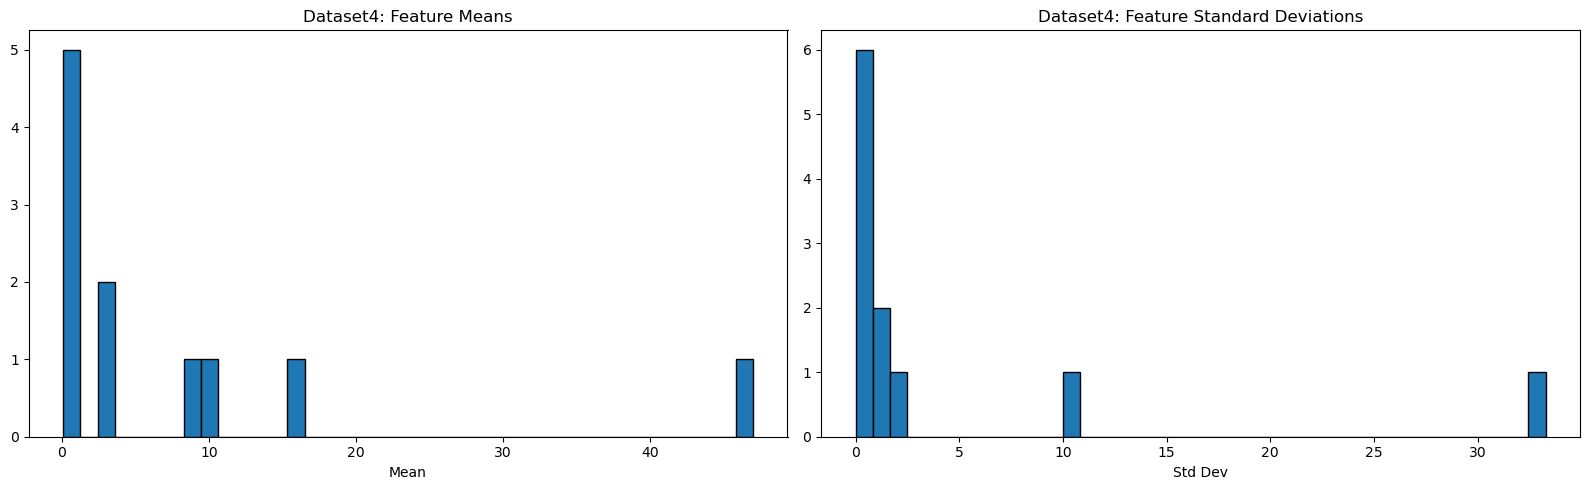

In [5]:
datasets_data = [
    ("Dataset1", TrainData1),
    ("Dataset2", TrainData2),
    ("Dataset3", TrainData3),
    ("Dataset4", TrainData4),
]

for title, df in datasets_data:

    df_clean = df.replace(1e99, np.nan)
    df_clean = df_clean.apply(pd.to_numeric, errors='coerce')

    feature_means = df_clean.mean(axis=0, skipna=True)
    feature_stds  = df_clean.std(axis=0, skipna=True)


    if feature_means.isna().all() or feature_stds.isna().all():
        print(f"\n=== {title} Summary ===")
        print("All feature means/stds are NaN. This usually means the file was not parsed correctly.")
        continue

    print(f"\n=== {title} Summary ===")
    print(f"Mean Range: {feature_means.min():.3f}  to  {feature_means.max():.3f}")
    print(f"Std Dev Range: {feature_stds.min():.3f}  to  {feature_stds.max():.3f}")

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 2, 1)
    plt.hist(feature_means.dropna(), bins=40, edgecolor='black')
    plt.title(f"{title}: Feature Means")
    plt.xlabel("Mean")

    plt.subplot(1, 2, 2)
    plt.hist(feature_stds.dropna(), bins=40, edgecolor='black')
    plt.title(f"{title}: Feature Standard Deviations")
    plt.xlabel("Std Dev")

    plt.tight_layout()
    plt.show()


## Clean & Impute (handle 1e99 + numeric)

In [6]:
MISSING_VAL = 1e99  

def clean_train(train_df):
    # Replace placeholder with NaN
    df = train_df.replace(MISSING_VAL, np.nan)
    
    df = df.apply(pd.to_numeric, errors="coerce")
    
    # Impute NaNs
    col_means = df.mean(axis=0)
    df = df.fillna(col_means)
    return df

X1_train_clean = clean_train(TrainData1)
X2_train_clean = clean_train(TrainData2)
X3_train_clean = clean_train(TrainData3)
X4_train_clean = clean_train(TrainData4)

for name, X in [("Dataset1", X1_train_clean),
                ("Dataset2", X2_train_clean),
                ("Dataset3", X3_train_clean),
                ("Dataset4", X4_train_clean)]:
    print(f"{name}: any NaN? ->", X.isna().any().any())


Dataset1: any NaN? -> False
Dataset2: any NaN? -> False
Dataset3: any NaN? -> False
Dataset4: any NaN? -> False


## Standardization (scaling for all datasets)


In [7]:
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train_clean)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train_clean)

scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train_clean)

scaler4 = StandardScaler()
X4_train_scaled = scaler4.fit_transform(X4_train_clean)

print("Scaled shapes:")
print("Dataset1:", X1_train_scaled.shape)
print("Dataset2:", X2_train_scaled.shape)
print("Dataset3:", X3_train_scaled.shape)
print("Dataset4:", X4_train_scaled.shape)


Scaled shapes:
Dataset1: (150, 3312)
Dataset2: (100, 9182)
Dataset3: (2547, 112)
Dataset4: (1119, 11)


## PCA + Cumulative Explained Variance Plots

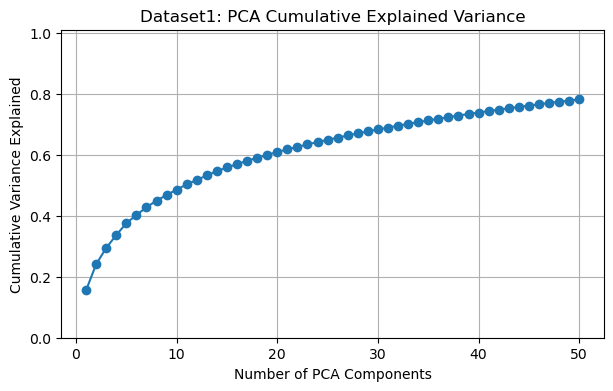

Dataset1: first 50 components explain 78.16% of the variance.


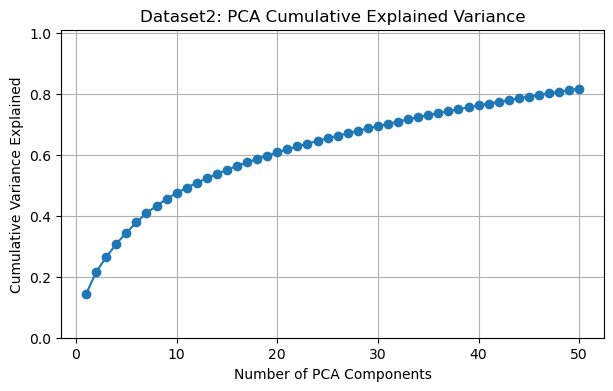

Dataset2: first 50 components explain 81.71% of the variance.


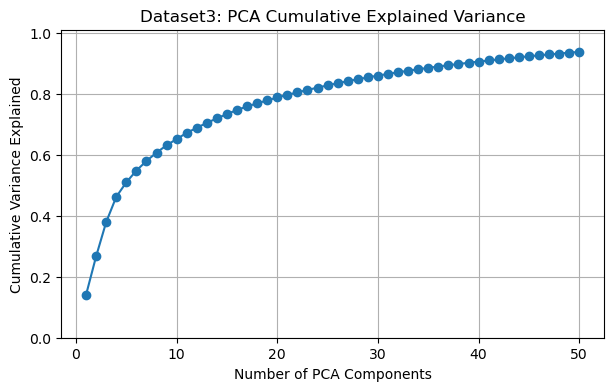

Dataset3: first 50 components explain 93.73% of the variance.
PCA shapes (train):
Dataset1: (150, 50)
Dataset2: (100, 50)
Dataset3: (2547, 50)
Dataset4 (no PCA): (1119, 11)


In [8]:
def run_pca_and_plot(X_scaled, n_components, title):
    pca = PCA(n_components=n_components, random_state=0)
    X_train_pca = pca.fit_transform(X_scaled)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(7, 4))
    plt.plot(range(1, n_components + 1), cumvar, marker="o")
    plt.title(f"{title}: PCA Cumulative Explained Variance")
    plt.xlabel("Number of PCA Components")
    plt.ylabel("Cumulative Variance Explained")
    plt.ylim(0, 1.01)
    plt.grid(True)
    plt.show()

    print(f"{title}: first {n_components} components explain "
          f"{cumvar[-1]*100:.2f}% of the variance.")
    return pca, X_train_pca, cumvar

# Run PCA on train sets only
pca1, X1_train_pca, cumvar1 = run_pca_and_plot(X1_train_scaled, 50, "Dataset1")
pca2, X2_train_pca, cumvar2 = run_pca_and_plot(X2_train_scaled, 50, "Dataset2")
pca3, X3_train_pca, cumvar3 = run_pca_and_plot(X3_train_scaled, 50, "Dataset3")

# Dataset4 is low dimensional
X4_train_pca = X4_train_scaled  

print("PCA shapes (train):")
print("Dataset1:", X1_train_pca.shape)
print("Dataset2:", X2_train_pca.shape)
print("Dataset3:", X3_train_pca.shape)
print("Dataset4 (no PCA):", X4_train_pca.shape)


## Choose Final PCA Dimensions

In [9]:
k1, k2, k3 = 40, 40, 30

X1_train_final = X1_train_pca[:, :k1]
X2_train_final = X2_train_pca[:, :k2]
X3_train_final = X3_train_pca[:, :k3]
X4_train_final = X4_train_pca          # no PCA

print("Final feature shapes for modeling:")
print("Dataset1:", X1_train_final.shape)
print("Dataset2:", X2_train_final.shape)
print("Dataset3:", X3_train_final.shape)
print("Dataset4:", X4_train_final.shape)


Final feature shapes for modeling:
Dataset1: (150, 40)
Dataset2: (100, 40)
Dataset3: (2547, 30)
Dataset4: (1119, 11)


## Model Comparison and Selection (Logistic Regression, SVM-RBF, KNN, Random Forest)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def evaluate_classifiers(X, y, dataset_name, n_pca=None):
   
    print(f"\n==================== {dataset_name} ====================")
    print(f"X shape: {X.shape} | y shape: {y.shape}")

    # Train/validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=42
    )

    steps = [("scaler", StandardScaler())]
    if n_pca is not None:
        from sklearn.decomposition import PCA
        steps.append(("pca", PCA(n_components=n_pca, random_state=42)))

    # Define models
    models = {
        "Logistic Regression": LogisticRegression(max_iter=3000),
        "SVM (RBF)": SVC(kernel="rbf", gamma="scale"),
        "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
    }

    results = []
    best_f1 = -1
    best_name = None
    best_pred = None

    for name, clf in models.items():
        pipe = Pipeline(steps + [("clf", clf)])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_val)

        acc = accuracy_score(y_val, pred)
        f1 = f1_score(y_val, pred, average="macro")

        print(f"{name}: Accuracy={acc:.4f} | Macro-F1={f1:.4f}")
        results.append({"Model": name, "Accuracy": acc, "Macro_F1": f1})

        if f1 > best_f1:
            best_f1 = f1
            best_name = name
            best_pred = pred

    # Results table
    results_df = pd.DataFrame(results).sort_values("Macro_F1", ascending=False)
    print("\n=== Sorted Performance Table ===")
    print(results_df.to_string(index=False))

    # Bar plot of macro F1
    plt.figure(figsize=(6, 4))
    plt.barh(results_df["Model"], results_df["Macro_F1"])
    plt.xlabel("Macro F1")
    plt.title(f"{dataset_name}: Model Comparison")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

    # Confusion matrix for best model
    cm = confusion_matrix(y_val, best_pred)
    classes = np.unique(y)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks(ticks=np.arange(len(classes)), labels=classes)
    plt.yticks(ticks=np.arange(len(classes)), labels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{dataset_name}: Best Model = {best_name}")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center", color="black", fontsize=8)

    plt.tight_layout()
    plt.show()

    return results_df, best_name


## Training Dataset 1


==================== Dataset1 ====================
X shape: (150, 3312) | y shape: (150,)
Logistic Regression: Accuracy=0.9667 | Macro-F1=0.9111
SVM (RBF): Accuracy=0.9667 | Macro-F1=0.9111
KNN (k=5): Accuracy=0.9667 | Macro-F1=0.9111
Random Forest: Accuracy=0.9000 | Macro-F1=0.8007

=== Sorted Performance Table ===
              Model  Accuracy  Macro_F1
Logistic Regression  0.966667  0.911111
          SVM (RBF)  0.966667  0.911111
          KNN (k=5)  0.966667  0.911111
      Random Forest  0.900000  0.800709


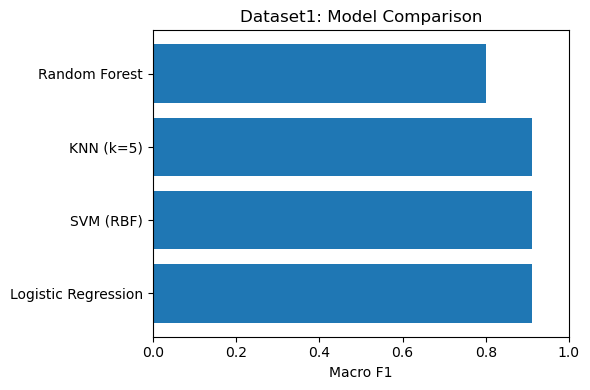

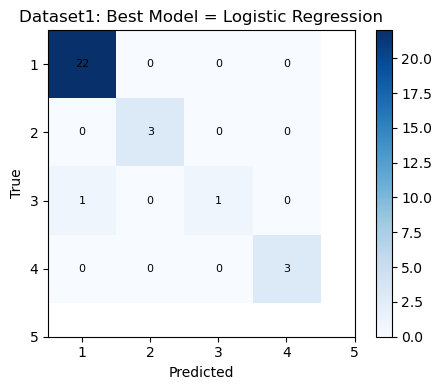

In [11]:
results_d1, best_d1 = evaluate_classifiers(
    X1_train_clean, TrainLabel1.values, "Dataset1", n_pca=40
)

## Training Dataset 2


==================== Dataset2 ====================
X shape: (100, 9182) | y shape: (100,)
Logistic Regression: Accuracy=0.8500 | Macro-F1=0.8636
SVM (RBF): Accuracy=0.8000 | Macro-F1=0.8247
KNN (k=5): Accuracy=0.8000 | Macro-F1=0.8030
Random Forest: Accuracy=0.8500 | Macro-F1=0.8576

=== Sorted Performance Table ===
              Model  Accuracy  Macro_F1
Logistic Regression      0.85  0.863636
      Random Forest      0.85  0.857576
          SVM (RBF)      0.80  0.824675
          KNN (k=5)      0.80  0.803030


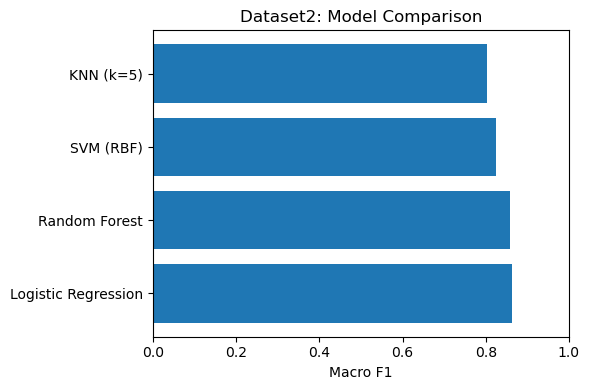

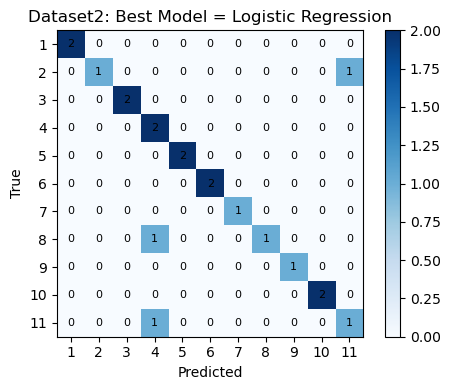

In [12]:
results_d2, best_d2 = evaluate_classifiers(
    X2_train_clean, TrainLabel2.values, "Dataset2", n_pca=40
)

## Training Dataset 3


==================== Dataset3 ====================
X shape: (2547, 112) | y shape: (2547,)
Logistic Regression: Accuracy=0.7235 | Macro-F1=0.7212
SVM (RBF): Accuracy=0.9020 | Macro-F1=0.9009
KNN (k=5): Accuracy=0.8471 | Macro-F1=0.8464
Random Forest: Accuracy=0.8529 | Macro-F1=0.8512

=== Sorted Performance Table ===
              Model  Accuracy  Macro_F1
          SVM (RBF)  0.901961  0.900931
      Random Forest  0.852941  0.851229
          KNN (k=5)  0.847059  0.846417
Logistic Regression  0.723529  0.721240


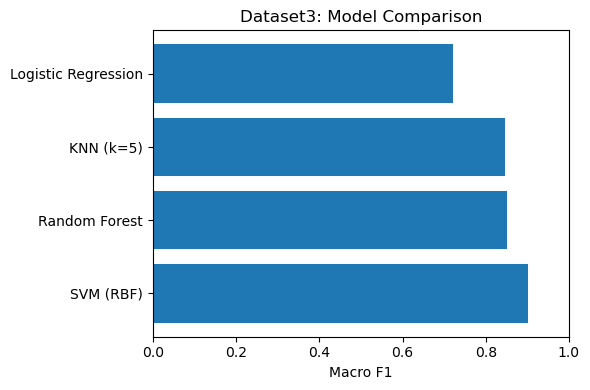

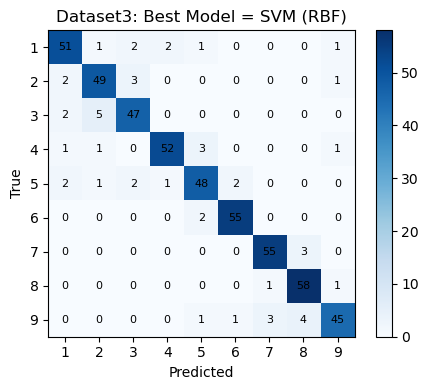

In [13]:
results_d3, best_d3 = evaluate_classifiers(
    X3_train_clean, TrainLabel3.values, "Dataset3", n_pca=30
)

## Training Dataset 4


==================== Dataset4 ====================
X shape: (1119, 11) | y shape: (1119,)
Logistic Regression: Accuracy=0.5982 | Macro-F1=0.2814
SVM (RBF): Accuracy=0.6161 | Macro-F1=0.2881
KNN (k=5): Accuracy=0.5759 | Macro-F1=0.2801
Random Forest: Accuracy=0.6830 | Macro-F1=0.3388

=== Sorted Performance Table ===
              Model  Accuracy  Macro_F1
      Random Forest  0.683036  0.338821
          SVM (RBF)  0.616071  0.288054
Logistic Regression  0.598214  0.281351
          KNN (k=5)  0.575893  0.280083


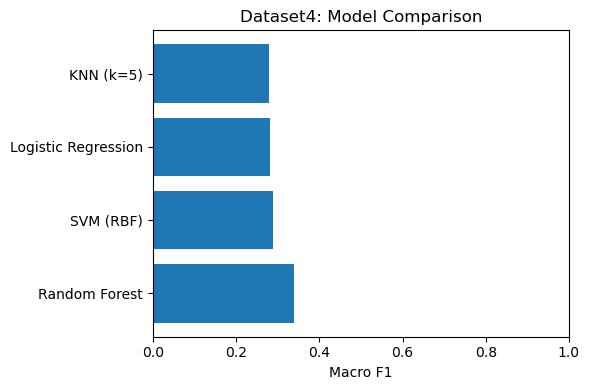

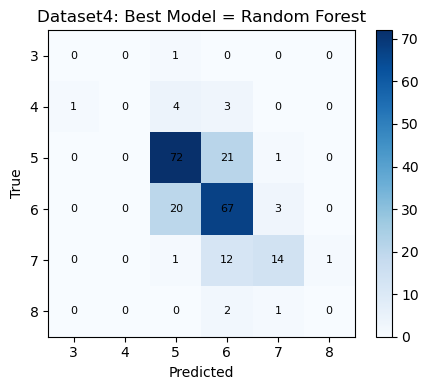

In [14]:
results_d4, best_d4 = evaluate_classifiers(
    X4_train_clean, TrainLabel4.values, "Dataset4", n_pca=None
)

## Combined Results

In [15]:
combined_results = pd.DataFrame({
    "Dataset": ["Dataset1", "Dataset2", "Dataset3", "Dataset4"],
    "Best_model": [best_d1, best_d2, best_d3, best_d4],
    "Best_Macro_F1": [
        results_d1["Macro_F1"].max(),
        results_d2["Macro_F1"].max(),
        results_d3["Macro_F1"].max(),
        results_d4["Macro_F1"].max()
    ],
    "Best_Accuracy": [
        results_d1.loc[results_d1["Macro_F1"].idxmax(), "Accuracy"],
        results_d2.loc[results_d2["Macro_F1"].idxmax(), "Accuracy"],
        results_d3.loc[results_d3["Macro_F1"].idxmax(), "Accuracy"],
        results_d4.loc[results_d4["Macro_F1"].idxmax(), "Accuracy"],
    ]
})

print("\n==== Combined Best Models Across Datasets ====")
print(combined_results.to_string(index=False))


==== Combined Best Models Across Datasets ====
 Dataset          Best_model  Best_Macro_F1  Best_Accuracy
Dataset1 Logistic Regression       0.911111       0.966667
Dataset2 Logistic Regression       0.863636       0.850000
Dataset3           SVM (RBF)       0.900931       0.901961
Dataset4       Random Forest       0.338821       0.683036


## Final Model Training for Test Prediction (Full Training Set)

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


means1 = X1_train_clean.mean(axis=0)
means2 = X2_train_clean.mean(axis=0)
means3 = X3_train_clean.mean(axis=0)
means4 = X4_train_clean.mean(axis=0)


final_pipes = {}

# Dataset 1: Logistic Regression + PCA(40)
final_pipes["D1"] = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=40, random_state=42)),
    ("clf", LogisticRegression(max_iter=3000))
])
final_pipes["D1"].fit(X1_train_clean, TrainLabel1.values)

# Dataset 2: Logistic Regression + PCA(40)
final_pipes["D2"] = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=40, random_state=42)),
    ("clf", LogisticRegression(max_iter=3000))
])
final_pipes["D2"].fit(X2_train_clean, TrainLabel2.values)

# Dataset 3: SVM (RBF) + PCA(30)
final_pipes["D3"] = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=30, random_state=42)),
    ("clf", SVC(kernel="rbf", gamma="scale"))
])
final_pipes["D3"].fit(X3_train_clean, TrainLabel3.values)

# Dataset 4: Random Forest (no PCA)
final_pipes["D4"] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])
final_pipes["D4"].fit(X4_train_clean, TrainLabel4.values)

print("Final models trained on full training data and stored in `final_pipes`.")


Final models trained on full training data and stored in `final_pipes`.


## Load Test Data

In [17]:
TestData1 = pd.read_csv("TestData1.txt", sep="\t", header=None)
TestData2 = pd.read_csv("TestData2.txt", sep=r"\s+", engine="python", header=None)
TestData3 = pd.read_csv("TestData3.txt", sep=r"\s+", engine="python", header=None)
TestData4 = pd.read_csv("TestData4.txt", sep=r"\s+", engine="python", header=None)

datasets_test = [
    ("TestData1", TestData1),
    ("TestData2", TestData2),
    ("TestData3", TestData3),
    ("TestData4", TestData4),
]


## Pre-process Test Data

In [18]:
from sklearn.metrics import accuracy_score, f1_score  

MISSING_VAL = 1e99

def clean_test_with_train_means(test_df, train_means):
    
    df = test_df.replace(MISSING_VAL, np.nan)
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.fillna(train_means)
    return df


X1_test_clean = clean_test_with_train_means(TestData1, means1)
X2_test_clean = clean_test_with_train_means(TestData2, means2)
X3_test_clean = clean_test_with_train_means(TestData3, means3)
X4_test_clean = clean_test_with_train_means(TestData4, means4)


print("Test shapes after cleaning:")
print("TestData1:", X1_test_clean.shape)
print("TestData2:", X2_test_clean.shape)
print("TestData3:", X3_test_clean.shape)
print("TestData4:", X4_test_clean.shape)

Test shapes after cleaning:
TestData1: (53, 3312)
TestData2: (74, 9182)
TestData3: (1092, 112)
TestData4: (480, 11)


## Run Models on Test Data and Save

In [19]:
preds1 = final_pipes["D1"].predict(X1_test_clean)
preds2 = final_pipes["D2"].predict(X2_test_clean)
preds3 = final_pipes["D3"].predict(X3_test_clean)
preds4 = final_pipes["D4"].predict(X4_test_clean)


def print_counts(name, preds):
    print(f"\n{name} predictions:")
    for label, count in pd.Series(preds).value_counts().sort_index().items():
        print(f"  Class {label}: {count}")

print_counts("Dataset1", preds1)
print_counts("Dataset2", preds2)
print_counts("Dataset3", preds3)
print_counts("Dataset4", preds4)


np.savetxt("ChowdhuryClassification1.txt", preds1.astype(int), fmt="%d")
np.savetxt("ChowdhuryClassification2.txt", preds2.astype(int), fmt="%d")
np.savetxt("ChowdhuryClassification3.txt", preds3.astype(int), fmt="%d")
np.savetxt("ChowdhuryClassification4.txt", preds4.astype(int), fmt="%d")



Dataset1 predictions:
  Class 1: 32
  Class 2: 3
  Class 3: 9
  Class 4: 6
  Class 5: 3

Dataset2 predictions:
  Class 1: 16
  Class 2: 1
  Class 3: 14
  Class 4: 12
  Class 6: 1
  Class 8: 18
  Class 10: 6
  Class 11: 6

Dataset3 predictions:
  Class 1: 123
  Class 2: 131
  Class 3: 139
  Class 4: 115
  Class 5: 111
  Class 6: 120
  Class 7: 113
  Class 8: 116
  Class 9: 124

Dataset4 predictions:
  Class 5: 218
  Class 6: 221
  Class 7: 39
  Class 8: 2
